# Experiments with Saliency Maps and Simulated Data:

In [468]:
%load_ext autoreload
%autoreload 2 


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [792]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn

from captum.attr import Saliency, InputXGradient, IntegratedGradients

from lfs.data import simulated as data

## Define `NeuralNetwork` Architecture and Training.

In [957]:
class SimulatedData(Dataset):
    def __init__(self, df, transform=None, target_transform=None):
        self.X = df.drop(columns=['y'])
        self.y = df['y']
        self.transform = transform
        self.target_transform = target_transform
        self.p = len(self.X.columns)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X.iloc[idx].values, dtype=torch.float32)
        y = torch.tensor(self.y.iloc[idx], dtype=torch.float32)
        if self.transform:
            x = self.transform(x)
        if self.target_transform:
            y = self.target_transform(y)
        return x, y

class NeuralNetwork(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(p, 40), 
            nn.ReLU(), 
            nn.Linear(40, 40), 
            nn.ReLU(), 
            nn.Linear(40, 1),
        )

    def forward(self, x):
        y_pred = self.linear_relu_stack(x)
        return y_pred    


class DeepNeuralNetwork(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(p, 40), 
            nn.ReLU(), 
            nn.Linear(40, 40), 
            nn.ReLU(), 
            nn.Linear(40, 40),
            nn.ReLU(), 
            nn.Linear(40, 40), 
            nn.ReLU(), 
            nn.Linear(40, 1),
        )

    def forward(self, x):
        y_pred = self.linear_relu_stack(x)
        return y_pred  

def add_pairwise_interactions(x):
    # x: (batch, p)
    # returns: (batch, p + p*(p-1)//2)
    pairs = []
    p = x.shape[1]
    for i in range(p):
        for j in range(i+1, p):
            pairs.append((x[:, i] * x[:, j]).unsqueeze(1))
    return torch.cat([x] + pairs, dim=1)

class InteractionNeuralNetwork(nn.Module):
    def __init__(self, p):
        super().__init__()
        p_aug = p + p * (p - 1) // 2  # e.g. p=10 → 10 + 45 = 55
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(p_aug, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        x = add_pairwise_interactions(x)
        return self.linear_relu_stack(x)

def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred.squeeze(1), y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)

### Define `learn_data(model, data, n, noise)`.

Takes in a simulated dataset from `src.dataset` and trains a neural network with the architecture from `NeuralNetwork` and returns the trained model.

In [517]:
def learn_data(model, function, n=1_000, noise=1, return_data=False):
    function = function(n=n, noise=noise)
    df = function
    dataset = SimulatedData(df)
    
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    device = "cpu"
    
    model = model(dataset.p).to(device)
    
    # Define Hyperparams
    learning_rate = 1e-3
    batch_size = 64
    epochs = 5
    
    # Initialize the loss function
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    epochs = 100
    for t in range(epochs):
        train_loop(dataloader, model, loss_fn, optimizer)
    print("Done!")
    
    # Generate test data
    test_df = function
    test_dataset = SimulatedData(test_df)
    
    X_test = torch.tensor(test_dataset.X.values, dtype=torch.float32).to(device)
    y_test = torch.tensor(test_dataset.y.values, dtype=torch.float32).to(device)
    
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).squeeze(1)
        test_mse = loss_fn(y_pred, y_test).item()
    
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Mean(y) = {y_test.mean()}")

    if return_data:
        return model, X_test, y_test
    return model

### Compare Models Ability on Different Learning Functions

In all models, $n$ samples are drawn with noise $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ i.i.d.

#### XOR Model

With $x_1, x_2 \sim \mathrm{Unif}(-1, 1)$ and $\sigma = 0.1$:

$$y = \mathbf{1}\{x_1 x_2 < 0\}, \qquad \tilde{x}_1 = x_1 + \varepsilon_1, \quad \tilde{x}_2 = x_2 + \varepsilon_2$$

where the noisy features $(\tilde{x}_1, \tilde{x}_2)$ are observed rather than $(x_1, x_2)$.

In [535]:
xor_model = learn_data(NeuralNetwork, data.XORModel , n=5_000, noise=1, return_data=True ) 

Done!
Test MSE: 0.2421
Mean(y) = 0.49779999256134033


#### Linear Additive Model

With $x_1, \dots, x_{10} \sim \mathcal{N}(0,1)$ and $\sigma = 0.1$:

$$y = 2x_1 + x_3 + 9x_5 + 9x_6 + 3x_7 + x_{10} + \varepsilon$$

In [537]:
linear_model = learn_data(NeuralNetwork, data.LinearAdditiveModel, n=5_000, noise=1, return_data=True)

Done!
Test MSE: 1.0351
Mean(y) = -0.13945497572422028


#### Nonlinear Additive Model

With $x_1, \dots, x_{10} \sim \mathcal{N}(0,1)$ and $\sigma = 0.01$:

$$y = 2x_1^2 + x_3^3 + 9\sin(x_5) + 9e^{x_6} + 3\cos(x_7) + |x_{10}| + \varepsilon$$

In [539]:
nonlinear_model = learn_data(NeuralNetwork, data.NonlinearAdditiveModel, n=5_000, noise=1, return_data=True)

Done!
Test MSE: 2.9775
Mean(y) = 19.191200256347656


#### Conditional Interaction Model

With $x_1, \dots, x_{10} \sim \mathcal{N}(0,1)$ and $\sigma = 0.1$:

$$y = 2\,x_1 x_2\,\mathbf{1}\{x_3 > 0\} + x_4 x_5\,\mathbf{1}\{x_3 < 0\} + 9\,x_6 x_7\,\mathbf{1}\{x_8 > 0\} + x_9 x_{10}\,\mathbf{1}\{x_8 < 0\} + \varepsilon$$

In [907]:
condint_model = learn_data(DeepNeuralNetwork, data.ConditionalInteractionModel , n=50_000, noise=0.1, return_data=True) 

Done!
Test MSE: 0.5234
Mean(y) = 0.03737480565905571


#### Logistic Model

With $x_1, \dots, x_{10} \sim \mathcal{N}(0,1)$, $\sigma = 0.1$, and sigmoid $s(z) = \frac{1}{1 + e^{-z}}$:

$$y = s\left(x_1^2 + x_3 x_4 + 4x_6 + 7x_8^2 + 2x_9^3\right) + \varepsilon$$

In [543]:
logistic_model = learn_data(NeuralNetwork, data.LogisticModel , n=5_000, noise=0.1, return_data=True) 

Done!
Test MSE: 0.0956
Mean(y) = 0.7690884470939636


## Calculate Saliency

In [919]:
def calculate_saliency(model, X, i):
    input = X[i].unsqueeze(0).requires_grad_(True)  # (1, 784)
    target = 0
    
    saliency = Saliency(model)
    attribution = saliency.attribute(input, target=target)

    return attribution

def bool_to_feature_set(bool_list):
    return {f"x{i+1}" for i, b in enumerate(bool_list) if b}

def saliency_feature_set(model, X, i, threshold):
    attr = calculate_saliency(model=model, X=X, i=i)
    bool_list = (attr > threshold)[0]
    
    return bool_to_feature_set(bool_list)

def threshold_dropouts(attr, step_size):
    dropouts = {}
    last_set = None
    max_attr = max(attr[0])
    for threshold in np.arange(0, max_attr + step_size, step_size):
        bool_list = (attr > threshold)[0]
        features_remaining = bool_to_feature_set(bool_list)
        if last_set is None:
            last_set = features_remaining
        dropped = last_set - features_remaining  # set difference, cleaner
        dropouts.update({x: threshold for x in dropped})
        last_set = features_remaining  # update for next iteration
    return dropouts

def plot_dropout_thresholds(attr, step_size=0.05, important_features=None, idx=None):
    dropouts = threshold_dropouts(attr, step_size)
    features = sorted(dropouts, key=lambda x: int(x[1:]))
    thresholds = [dropouts[f] for f in features]
    colors = ['#2196F3' if important_features and f in important_features else '#E0E0E0' for f in features]

    plt.figure(figsize=(12, 4))

    if important_features:
        unimportant_thresholds = [t for f, t in zip(features, thresholds) if f not in important_features]
        if unimportant_thresholds:
            plt.axhline(y=max(unimportant_thresholds), color='red', linestyle=':', linewidth=1.5, label='max unimportant')
            plt.legend()

    plt.bar(features, thresholds, color=colors, edgecolor='white', linewidth=0.5)
    plt.ylim(0, float(attr.max()) * 1.05)
    plt.xlabel('Feature')
    plt.ylabel('Dropout threshold')
    plt.title(f'Saliency for Observation {idx}')
    plt.tight_layout()
    plt.show()

S_star = {
    'XORModel' : {'x1', 'x2'},
    'LinearAdditiveModel' : {'x1', 'x3', 'x5', 'x6', 'x7', 'x10'},
    'NonlinearAdditiveModel' : {'x1', 'x3', 'x5', 'x6', 'x7', 'x10'},
    'LogisticModel' : {'x1', 'x3', 'x4', 'x6', 'x8', 'x9'}
}

def true_important_features(x):
    """
    x: 1D tensor or array of length >= 10, 0-indexed
    Returns a set of feature name strings e.g. {'x1', 'x2', 'x3'}
    """
    important = {6, 7, 8}  # x6, x7, x8 always matter (x8 is the indicator)

    if x[2] > 0:       # x3 > 0: first term active
        important |= {1, 2, 3}   # x1, x2, x3
    elif x[2] < 0:     # x3 < 0: second term active
        important |= {2, 4, 5}   # x3, x4, x5

    if x[7] > 0:       # x8 > 0: third term active
        important |= {6, 7, 8}   # x6, x7, x8
    elif x[7] < 0:     # x8 < 0: fourth term active
        important |= {8, 9, 10}  # x8, x9, x10

    return {f"x{i}" for i in important}

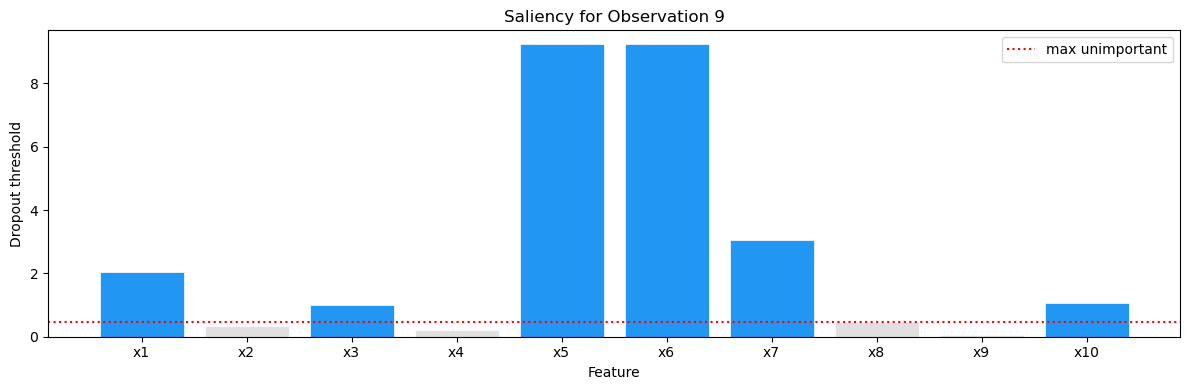

In [1037]:
i = 9
attr = calculate_saliency(model=linear_model[0], X=linear_model[1], i=i)
plot_dropout_thresholds(attr, step_size=0.05, important_features=S_star['LinearAdditiveModel'], idx=i)

Interestingly, the linear model's graph is fairly consistent across observations, but the nonlinear model has a lot more variance in its shape

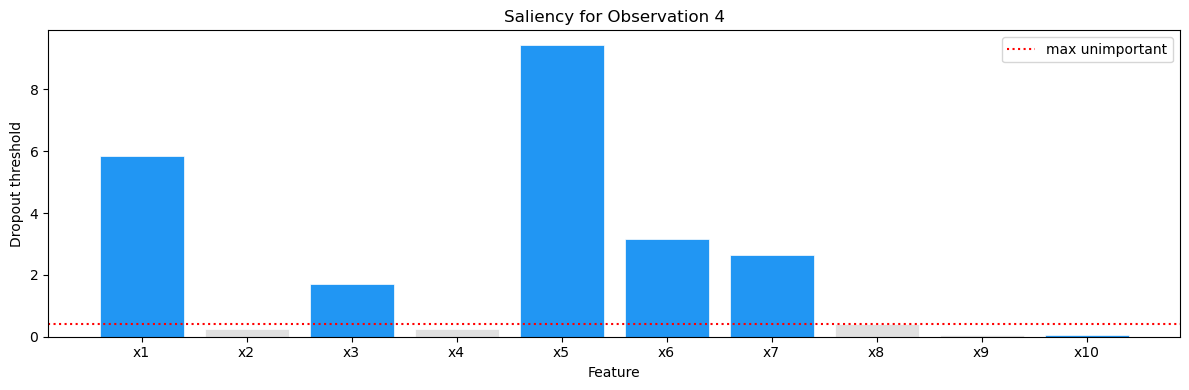

In [1043]:
i = 4
attr = calculate_saliency(model=nonlinear_model[0], X=nonlinear_model[1], i=i)
plot_dropout_thresholds(attr, step_size=0.05, important_features=S_star['NonlinearAdditiveModel'], idx=i)

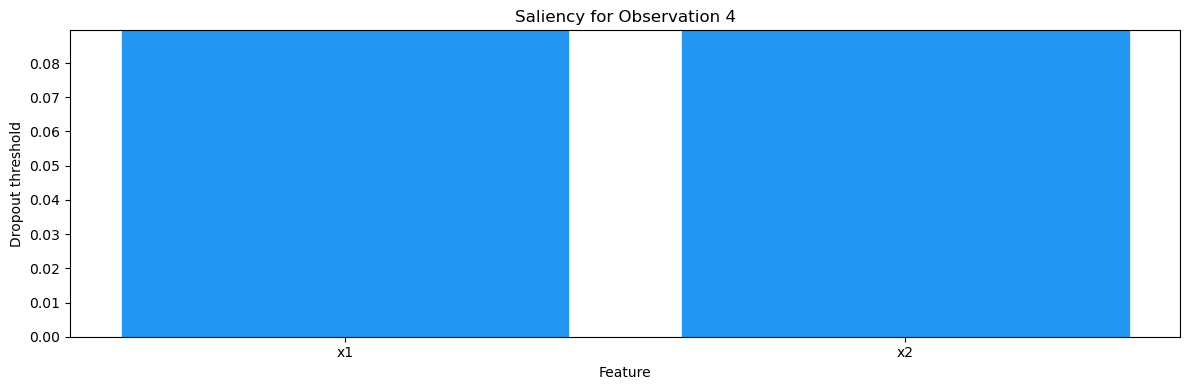

In [885]:
i = 4
attr = calculate_saliency(model=xor_model[0], X=xor_model[1], i=i)
plot_dropout_thresholds(attr, step_size=0.05, important_features=S_star['XORModel'], idx=i)

Done!
Test MSE: 1.0813
Mean(y) = 0.034048814326524734


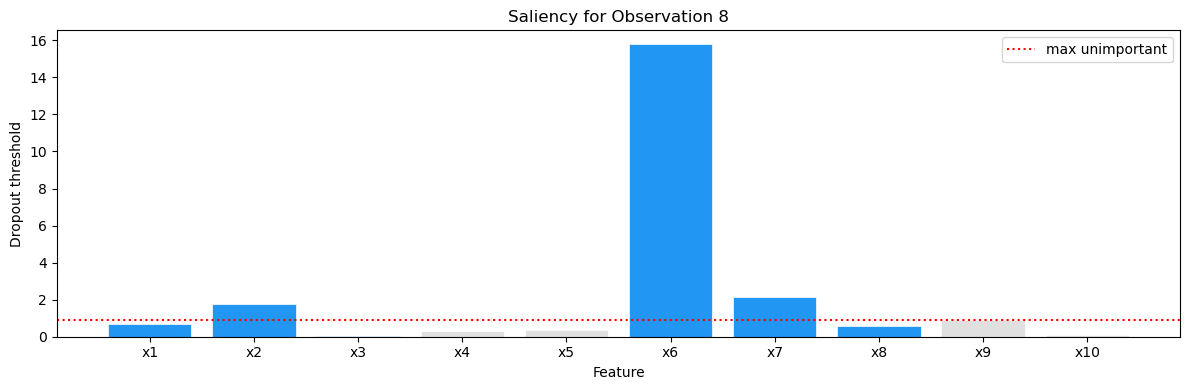

In [945]:
condint_model = learn_data(InteractionNeuralNetwork, data.ConditionalInteractionModel , n=50_000, noise=0.1, return_data=True) 

In [1059]:
class InteractionNeuralNetwork(nn.Module):
    def __init__(self, p):
        super().__init__()
        p_aug = p + p * (p - 1) // 2  # e.g. p=10 → 10 + 45 = 55
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(p_aug, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        x = add_pairwise_interactions(x)
        return self.linear_relu_stack(x)

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class ResidualNetwork(nn.Module):
    def __init__(self, p, hidden_dim=128, n_blocks=3):
        super().__init__()
        p_aug = p + p * (p - 1) // 2
        self.input_proj = nn.Sequential(
            nn.Linear(p_aug, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim) for _ in range(n_blocks)]
        )
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = add_pairwise_interactions(x)
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.output(x)

condint_model = learn_data(NeuralNetwork, data.ConditionalInteractionModel,n=50_000, noise=0.1, return_data=True )

Done!
Test MSE: 0.8942
Mean(y) = -0.019111651927232742


In [1060]:
condint_model_deep = learn_data(DeepNeuralNetwork, data.ConditionalInteractionModel,n=50_000, noise=0.1, return_data=True )

Done!
Test MSE: 0.6850
Mean(y) = -0.07047931849956512


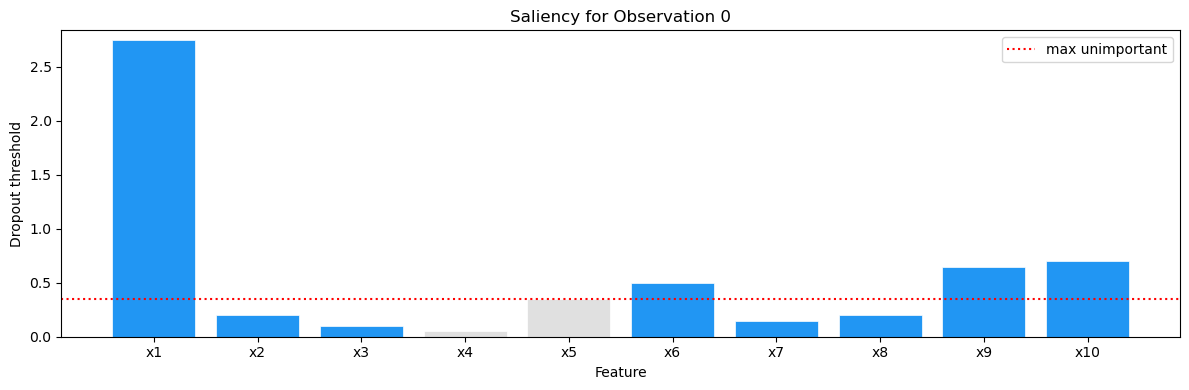

In [1057]:
i = 0
attr = calculate_saliency(model=condint_model[0], X=condint_model[1], i=i)
plot_dropout_thresholds(attr, important_features=true_important_features(condint_model[1][i]), idx=i)

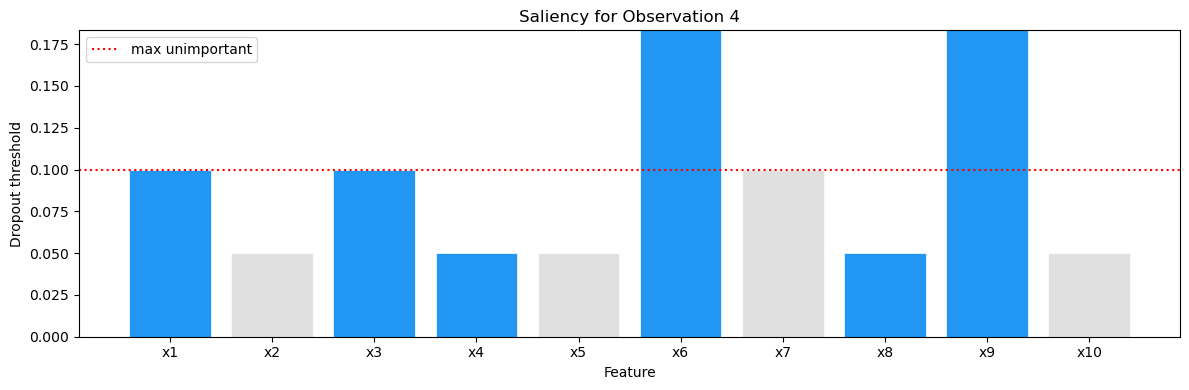

In [1062]:
i = 4
attr = calculate_saliency(model=logistic_model[0], X=logistic_model[1], i=i)
plot_dropout_thresholds(attr, step_size=0.05, important_features=S_star['LogisticModel'], idx=i)

In [1086]:
model = condint_model[0]
X_test = condint_model[1]
y_test = condint_model[2]
y_pred = model(X_test)

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

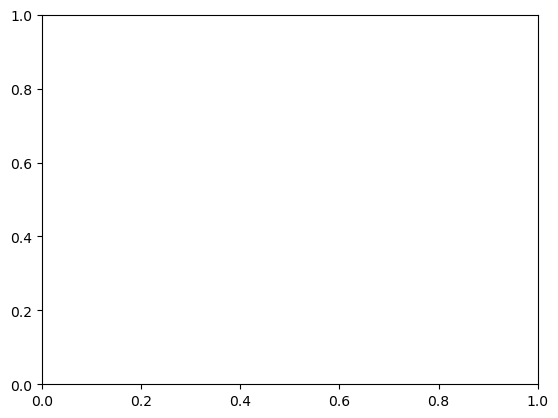

In [1078]:
plt.scatter(y_test, y_pred)

In [1098]:
y_pred

tensor([[ 3.6941],
        [ 0.5352],
        [-1.9629],
        ...,
        [ 3.2785],
        [-3.0097],
        [-1.9809]], grad_fn=<AddmmBackward0>)